**Notebook di esplorazione del dataset formato dai progetti di DH finanziati dal PRIN-PNRR 2022**

In [2]:
import pandas as pd

In [ ]:
dataset_prin_pnrr_2022 = "../dataset/prin_pnrr_2022/prin_pnrr_2022.csv"

prin_pnrr_2022 = pd.read_csv(dataset_prin_pnrr_2022)

In [4]:
prin_pnrr_2022.info()

<class 'pandas.DataFrame'>
RangeIndex: 88 entries, 0 to 87
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   progetto       88 non-null     str  
 1   istituzione    88 non-null     str  
 2   finanziamento  88 non-null     int64
 3   sito web       72 non-null     str  
dtypes: int64(1), str(3)
memory usage: 2.9 KB


In [5]:
finanziamenti_totali = prin_pnrr_2022["finanziamento"].sum()

int(finanziamenti_totali)

20352480

In [25]:
media = prin_pnrr_2022["finanziamento"].mean()

mediana = prin_pnrr_2022["finanziamento"].median()

print(f"media = {media}")
print(f"mediana = {mediana}")

media = 231278.18181818182
mediana = 230666.0


Il PRIN-PNRR 2022 ha finanziato **88** progetti di DH in Italia, per un totale di **€ 20.352.480**

In [6]:
prin_pnrr_2022["pnrr"] = "PRIN 2022 - PNRR"

prin_pnrr_2022.head()

,progetto,istituzione,finanziamento,sito web,pnrr
0,DAFNE (Democratic governance of Automated syst...,Università di Bologna,241820,unibo.it/it/ricerca/progetti-e-iniziative/prin...,PRIN 2022 - PNRR
1,"Translating, Encoding, Sharing The Origins. Fr...",ILC-CNR – Pisa,242939,https://dbtvm1.ilc.cnr.it/digesto/,PRIN 2022 - PNRR
2,Defending Art,Università di Trento,242325,https://r1.unitn.it/defendingart/,PRIN 2022 - PNRR
3,Textus galloromanici vetustiores,Università di Chieti e Pescara,284558,https://sifr.it/sifr_new/convegno-le-prime-tes...,PRIN 2022 - PNRR
4,Space and Time in Oral Archives,Università di Urbino,278448,https://sites.google.com/unisi.it/stoaproject/...,PRIN 2022 - PNRR


Analizziamo ora i dati del PRIN "classico" 2022

In [7]:
dataset_prin_2022 = "../dataset/prin_2022/dh_prin_2022.csv"

prin_2022 = pd.read_csv(dataset_prin_2022)

prin_2022.info()

<class 'pandas.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   codice         51 non-null     str  
 1   progetto       51 non-null     str  
 2   istituzione    51 non-null     str  
 3   finanziamento  51 non-null     int64
dtypes: int64(1), str(3)
memory usage: 1.7 KB


In [8]:
finanziamenti_totali = prin_2022["finanziamento"].sum()

int(finanziamenti_totali)

12419545

In [23]:
media = prin_2022["finanziamento"].mean()

mediana = prin_2022["finanziamento"].median()

print(f"media = {media}")
print(f"mediana = {mediana}")

media = 243520.49019607843
mediana = 246248.0


In [9]:
prin_2022["pnrr"] = "PRIN 2022"
prin_2022.head()

,codice,progetto,istituzione,finanziamento,pnrr
0,2022KFLF3E,"EquAl: Equitable Algorithms, Promoting Fairnes...",Università degli studi di BOLOGNA,242691,PRIN 2022
1,20228W9NE7,Caring for Children with an Immigrant Backgrou...,Università degli studi di ROMA La Sapienza,220000,PRIN 2022
2,202297CKET,ALGOLIT: Understanding and boosting algorithmi...,Università degli Studi di TRENTO,197997,PRIN 2022
3,2022YRJ83A,Feedback culture: assessing the effects of alg...,Università degli Studi di MILANO,211378,PRIN 2022
4,2022Z78M8J,The Digital Transition and the World of Work: ...,Università degli studi di BARI ALDO MORO,246248,PRIN 2022


In [10]:
join = [prin_pnrr_2022, prin_2022]
join_df = pd.concat(join, ignore_index=True)

#join_df.drop(columns = ["codice", "sito web", "istituzione"], inplace=True)

#join_final = pd.concat(tutti_join_df, ignore_index=True)
#join_df = cup.merge(fin, on="codice", how="left")

join_df.head()

,progetto,istituzione,finanziamento,sito web,pnrr,codice
0,DAFNE (Democratic governance of Automated syst...,Università di Bologna,241820,unibo.it/it/ricerca/progetti-e-iniziative/prin...,PRIN 2022 - PNRR,NaN
1,"Translating, Encoding, Sharing The Origins. Fr...",ILC-CNR – Pisa,242939,https://dbtvm1.ilc.cnr.it/digesto/,PRIN 2022 - PNRR,NaN
2,Defending Art,Università di Trento,242325,https://r1.unitn.it/defendingart/,PRIN 2022 - PNRR,NaN
3,Textus galloromanici vetustiores,Università di Chieti e Pescara,284558,https://sifr.it/sifr_new/convegno-le-prime-tes...,PRIN 2022 - PNRR,NaN
4,Space and Time in Oral Archives,Università di Urbino,278448,https://sites.google.com/unisi.it/stoaproject/...,PRIN 2022 - PNRR,NaN


In [11]:
pnrr_proj = join_df.groupby("pnrr")["progetto"].count()

pnrr_proj.head()

pnrr
PRIN 2022           51
PRIN 2022 - PNRR    88
Name: progetto, dtype: int64

[Text(0, 3, '51'), Text(0, 3, '88')]

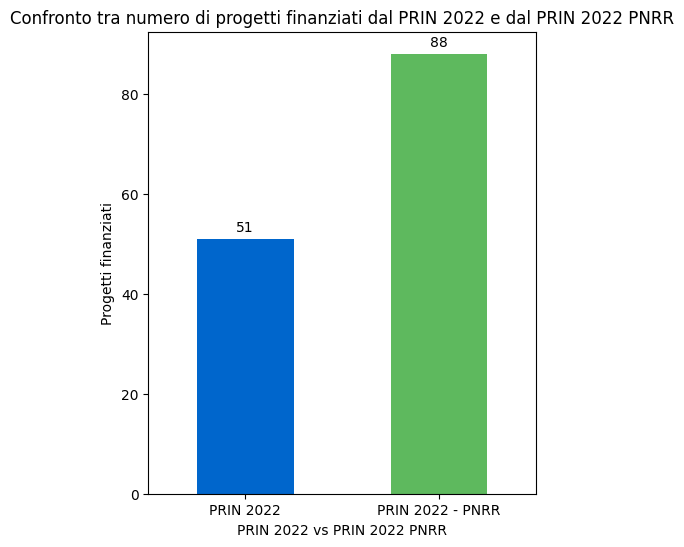

In [36]:
ax = pnrr_proj.plot(
    kind = "bar",
    x = "pnrr",
    color = ["#0066cc", "#5eb95e"],
    xlabel = "PRIN 2022 vs PRIN 2022 PNRR",
    ylabel = "Progetti finanziati",
    title = "Confronto tra numero di progetti finanziati dal PRIN 2022 e dal PRIN 2022 PNRR",
    # grid = True
    rot=0,
    figsize=(5,6)
)

ax.bar_label(ax.containers[0], padding=3)

In [13]:
pnrr_fin = join_df.groupby("pnrr")["finanziamento"].sum()

pnrr_fin.head()

pnrr
PRIN 2022           12419545
PRIN 2022 - PNRR    20352480
Name: finanziamento, dtype: int64

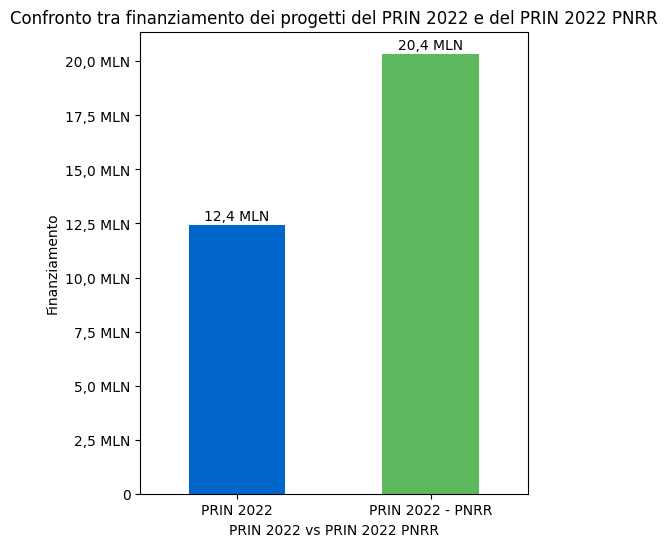

In [53]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

ax = pnrr_fin.plot(
    kind = "bar",
    x = "pnrr",
    y = "progetti",
    color = ["#0066cc", "#5eb95e"],
    xlabel = "PRIN 2022 vs PRIN 2022 PNRR",
    ylabel = "Finanziamento",
    title = "Confronto tra finanziamento dei progetti del PRIN 2022 e del PRIN 2022 PNRR",
    figsize = (5, 6),
    rot=0
)

def formatta_mln(x, pos):
    valore_milioni = x / 1_000_000
    if valore_milioni == 0:
        return "0"
    return f"{valore_milioni:.1f}".replace('.', ',') + " MLN"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(formatta_mln))


for container in ax.containers:
    labels = []
    for bar in container:
        altezza = bar.get_height()
        valore_milioni = altezza / 1_000_000
        stringa_formattata = f"{valore_milioni:.1f}".replace('.', ',') + " MLN"
        labels.append(stringa_formattata)
    
    ax.bar_label(container, labels=labels, padding=1)

plt.show()